1. Introduction

This project focuses on detecting fraudulent credit card transactions using machine learning techniques.

2. Dataset Description

The dataset contains credit card transactions with features transformed using PCA. The target variable indicates fraud or normal transactions.

In [104]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


3. Data Analysis

The dataset is highly imbalanced, with very few fraud transactions compared to normal ones.

In [105]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [106]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


The dataset is highly imbalanced, with only 0.23% of transactions labeled as fraud. This makes fraud detection challenging because machine learning models may become biased toward predicting normal transactions.

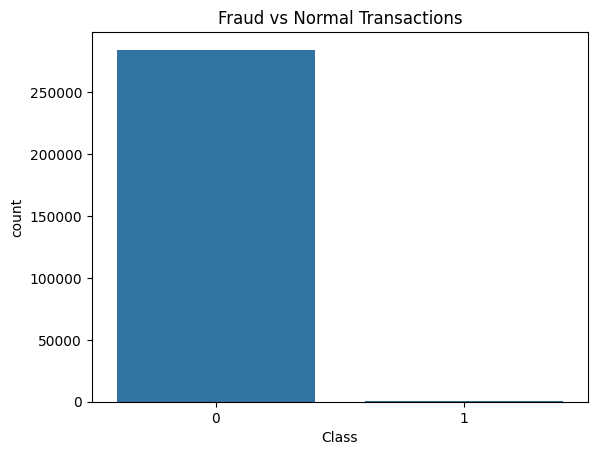

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

The visualization clearly shows that normal transactions dominate the dataset, while fraudulent transactions are extremely rare. This confirms the class imbalance problem.

4. Data Preprocessing

The data is split into training and testing sets. Since the dataset is imbalanced, upsampling is applied to balance the classes.

In [108]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [109]:
from sklearn.utils import resample
import pandas as pd

train = pd.concat([X_train, y_train], axis=1)

fraud = train[train.Class == 1]
normal = train[train.Class == 0]

fraud_upsampled = resample(
    fraud,
    replace=True,
    n_samples=len(normal),
    random_state=42
)

train_balanced = pd.concat([normal, fraud_upsampled])

X_train = train_balanced.drop('Class', axis=1)
y_train = train_balanced['Class']

In [110]:
y_train.value_counts()

,count
Class,
0,227451
1,227451


In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Feature Engineering

New features were created from the transaction amount to improve model performance.
The amount was categorized into bins and scaled to normalize the data.

In [112]:
# Feature Engineering
df['Amount_Category'] = pd.qcut(df['Amount'], 4, labels=False)

df['Amount_scaled'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()

df = df.drop(['Amount'], axis=1)

6. Model Building

Logistic Regression is used to train the fraud detection model.

In [113]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

7. Evaluation

The model is evaluated using confusion matrix and classification report.

In [114]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[55517  1347]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [115]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9762122116498718


8. Anomaly Detection

Isolation Forest is used as an unsupervised learning technique to detect anomalies in the dataset.
It identifies rare patterns that differ significantly from normal transactions, which may indicate fraud.

In [116]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X_train)

# Predict
y_pred_iso = iso.predict(X_test)

# Convert output: -1 → fraud (1), 1 → normal (0)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_iso))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.20      0.03      0.05        98

    accuracy                           1.00     56962
   macro avg       0.60      0.52      0.53     56962
weighted avg       1.00      1.00      1.00     56962



Anomaly Detection:

In addition to classification, anomaly detection was implemented using Isolation Forest. This method identifies unusual patterns in transaction data, which may indicate fraudulent activity. It is useful in real-world scenarios where fraud patterns constantly evolve.

9. Real-Time Simulation

A sample transaction is passed to the model to simulate real-time fraud detection.

In [117]:
# Simulate real-time prediction
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction Detected 🚨")
else:
    print("Normal Transaction ✅")

Fraud Transaction Detected 🚨


Real-Time Simulation:

A simple real-time prediction system was simulated where new transaction data can be passed to the model to detect fraud instantly.

10. Conclusion

This project demonstrates how machine learning can effectively detect fraudulent transactions, especially when handling imbalanced data.